# __EDA__

# __Análisis Exploratorio y búsqueda de insights__

Aplicar EDA sobre los datos limpios para entender la composicion y las relaciones entre variables. Se busca visualizar y describir los datos para detectar patrones para luego ser usado en la identificacion de features del modelado.

## Librerías

In [1]:
# librerias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Estilo de graficas
sns.set_theme(style="whitegrid")

# Tamano de las graficas
sns.set(
    rc={
        'figure.figsize':(8, 8)
    }
)

## Carga de datos limpios

In [3]:
# Cargamos el dataset ya limpio, generado en 01_limpieza_datos.ipynb
data = pd.read_csv('employees_cleaned.csv')
data

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,HR,4,Bachelors,f,other,1,31,3.0,5,0,0,51
1,Sales & Marketing,13,Bachelors,m,other,1,31,1.0,4,0,0,47
2,Procurement,2,Bachelors,f,other,3,31,2.0,9,0,0,65
3,Finance,29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61
4,Procurement,7,Bachelors,m,sourcing,1,36,3.0,2,0,0,68
...,...,...,...,...,...,...,...,...,...,...,...,...
15411,Sales & Marketing,31,Bachelors,m,other,1,42,3.0,10,0,0,53
15412,Sales & Marketing,25,Bachelors,m,sourcing,2,28,2.0,5,0,0,45
15413,Technology,7,Bachelors,f,referred,2,30,5.0,6,1,0,81
15414,HR,7,Bachelors,m,other,1,33,1.0,9,0,0,51


## Distribución de género

### Cantidad por género

In [4]:
# conteo de genero
gender_counts = data['gender'].value_counts()
gender_counts

gender
m    10806
f     4610
Name: count, dtype: int64

In [5]:
male_count = (data['gender'] == 'm').sum()
female_count = (data['gender'] == 'f').sum()

print('Total de empleados hombres: ',male_count)
print('Total de empleados mujeres: ', female_count)

Total de empleados hombres:  10806
Total de empleados mujeres:  4610


### Pie chart de género

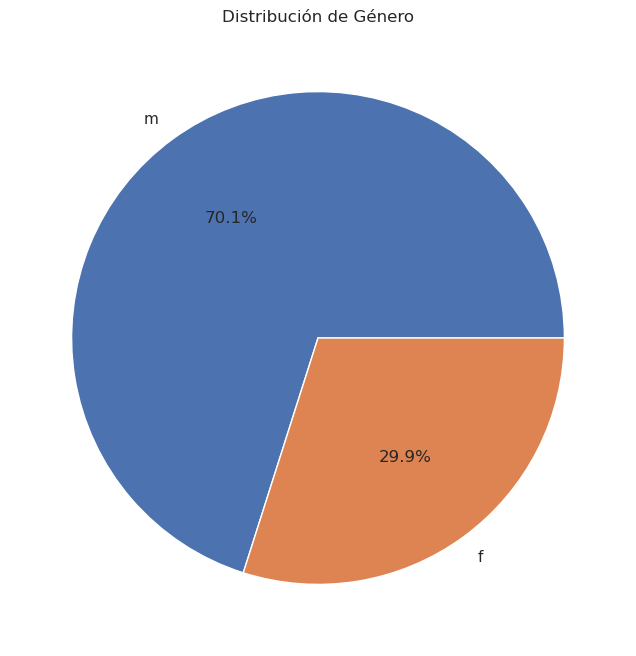

In [6]:
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
plt.title('Distribución de Género');

> Se evidencia que la mayoría de los empleados son hombres.

## Distribución canales de reclutamiento

### Cantidad por canales

In [7]:
recruit_counts = data['recruitment_channel'].value_counts()
recruit_counts

recruitment_channel
other       8656
sourcing    6473
referred     287
Name: count, dtype: int64

In [8]:
other_count = (data['recruitment_channel'] == 'other').sum()
sourcing_count = (data['recruitment_channel'] == 'sourcing').sum()
referred_count = (data['recruitment_channel'] == 'referred').sum()

print('Cantidad de empleado que ingresaron por referencia: ', referred_count)
print('Cantidad de empleado que ingresaron por propia cuenta: ', sourcing_count)
print('Cantidad de empleado que ingresaron por otro metodo: ', other_count)

Cantidad de empleado que ingresaron por referencia:  287
Cantidad de empleado que ingresaron por propia cuenta:  6473
Cantidad de empleado que ingresaron por otro metodo:  8656


### Pie chart de canales de reclutamiento

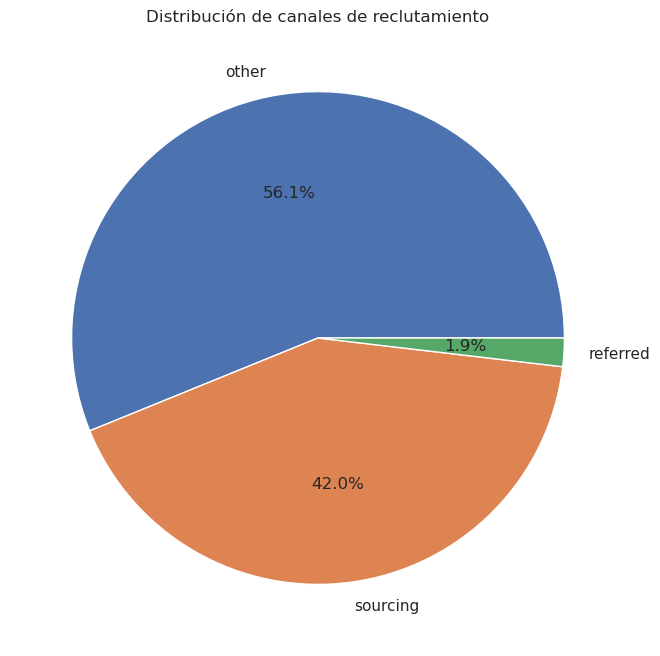

In [9]:
plt.pie(recruit_counts, labels= recruit_counts.index, autopct='%1.1f%%')
plt.title('Distribución de canales de reclutamiento');

> Se evidencia que gran parte de los empleados ingresaron a la empresa por otros medios.

## Nivel educativo según el género

### Cantidad por nivel educativo

In [10]:
# Conteo segun eduacion
basic_count = (data['education'] == 'Below Secondary').sum()
bach_count = (data['education'] == 'Bachelors').sum()
mast_count = (data['education'] == 'Masters & above').sum()

print(f'Nivel educativo Basico: {basic_count} empleados')
print(f'Nivel educativo Bachillerato: {bach_count} empleados')
print(f'Nivel educativo Maestria: {mast_count} empleados')

Nivel educativo Basico: 168 empleados
Nivel educativo Bachillerato: 10459 empleados
Nivel educativo Maestria: 4789 empleados


### Visualización de nivel educativo según el género

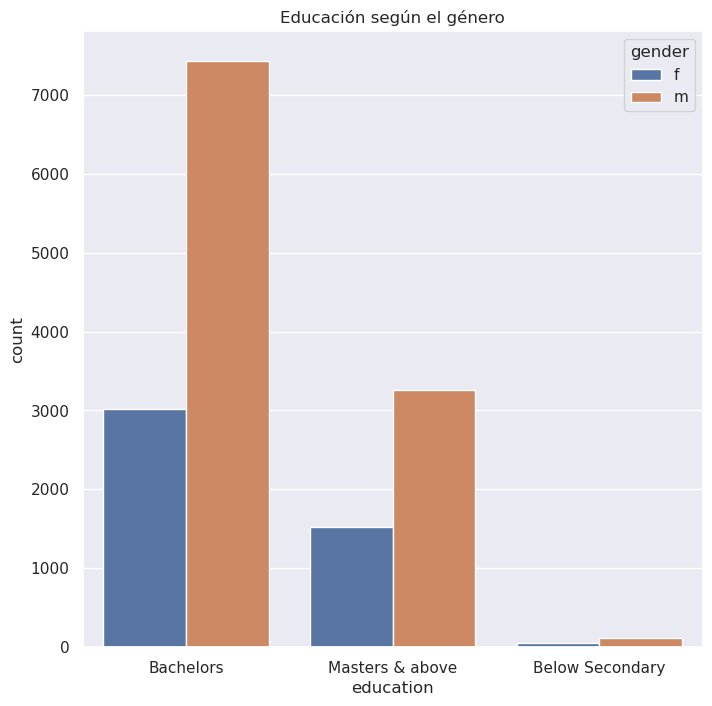

In [11]:
sns.countplot(data=data, x=data['education'], hue=data['gender'])
plt.title('Educación según el género');

> Todos los niveles educativos están dominados por hombres, en una proporción similar a la del total de empleados. La gran mayoría de los empleados, sin importar el género, cuentan con estudios de Bachillerato.

## Cumplimiento de KPIs

### Tasa de KPIs

In [12]:
# Conteo de empleados segun el cumplimiento de mas del 80% de KPIs
KPI_counts = data['KPIs_met_more_than_80'].value_counts()
KPI_counts

KPIs_met_more_than_80
0    9841
1    5575
Name: count, dtype: int64

In [13]:
cumplen = (data['KPIs_met_more_than_80'] == 1).sum()
no_cumplen = (data['KPIs_met_more_than_80'] == 0).sum()

total = cumplen + no_cumplen
pct_cumplen = (cumplen/total)*100
pct_no_cumplen = (no_cumplen/total)*100
print(f'Tasa de cumplimiento de KPIs : \n- {pct_no_cumplen:.2f}% de los empleados no cumplen con mas del 80% de los KPIs\n- {pct_cumplen:.2f}% de los empleados cumplen con mas del 80% de los KPIs')

Tasa de cumplimiento de KPIs : 
- 63.84% de los empleados no cumplen con mas del 80% de los KPIs
- 36.16% de los empleados cumplen con mas del 80% de los KPIs


### Visualización de cumplimiento de KPIs

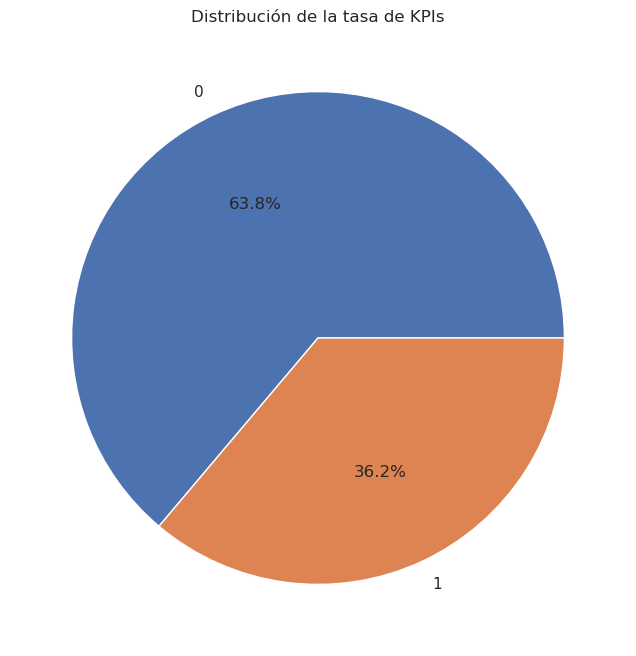

In [14]:
plt.pie(KPI_counts, labels=KPI_counts.index, autopct='%1.1f%%')
plt.title('Distribución de la tasa de KPIs');

> 63.8% de los empleados no cumplen con más del 80% de los KPIs.

## Distribución de edad

In [15]:
# Estadistica basica sobre edad
data['age'].agg(['min','mean','median','max','std','skew']).to_frame().T

,min,mean,median,max,std,skew
age,20.0,35.633044,34.0,60.0,7.576211,0.991874


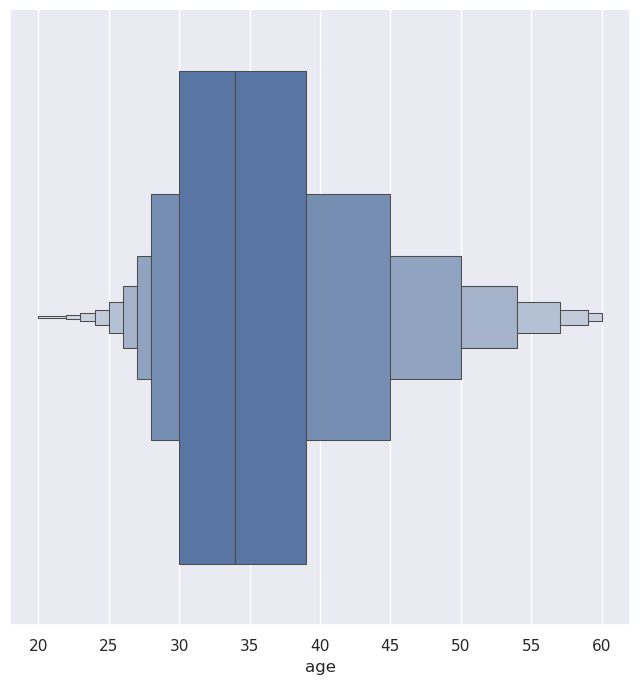

In [16]:
# Visualizacion de la distribucion de edad
sns.boxenplot(x=data['age']);

> La gráfica indica que el rango de edad de la mayoría de los empleados está entre los 30 y 39 años.

## Distribución de la duración en el trabajo

In [17]:
data['length_of_service'].agg(['min','mean','median','max','std','skew']).to_frame().T

,min,mean,median,max,std,skew
length_of_service,1.0,6.258108,5.0,34.0,4.115144,1.751104


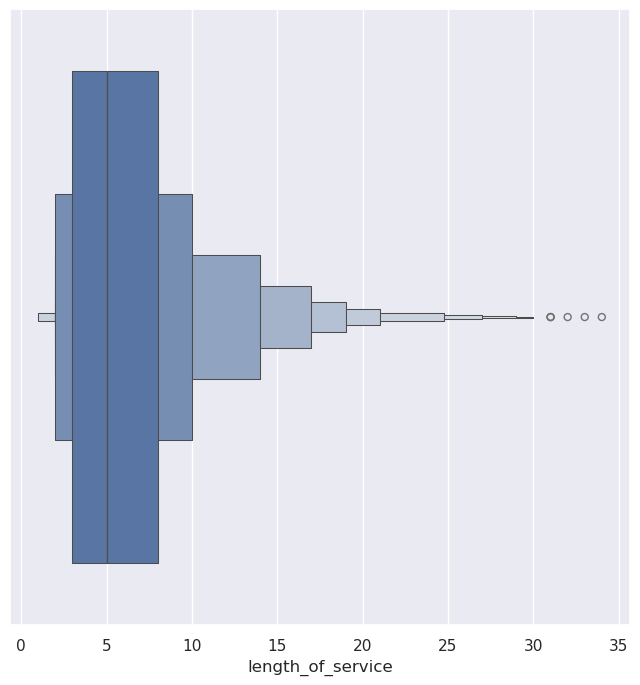

In [18]:
# visualizacion de duracion del servicio
sns.boxenplot(x=data['length_of_service']);

> El rango de tiempo en el trabajo está entre 4 y 8 años.

## Distribución del número de capacitaciones

In [19]:
# Estadistica basica del tiempo de entrenamiento
data['no_of_trainings'].agg(['min','mean','median','max','std','skew']).to_frame().T

,min,mean,median,max,std,skew
no_of_trainings,1.0,1.2476,1.0,9.0,0.588676,3.404001


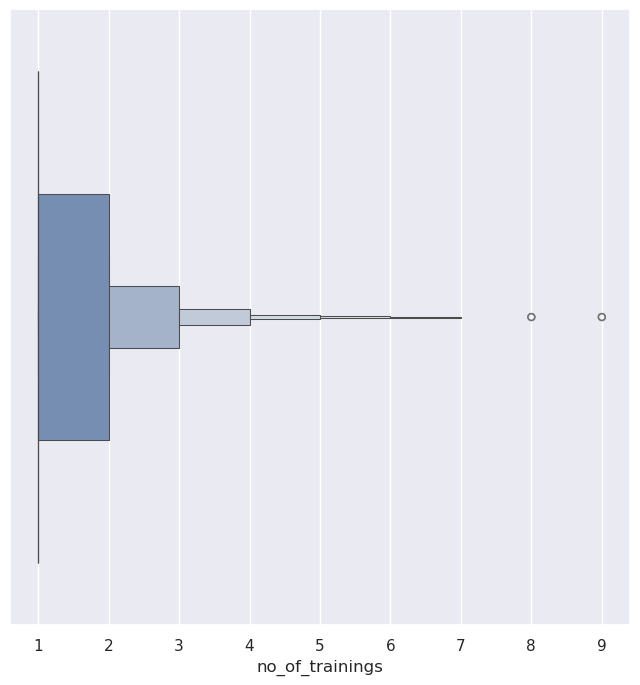

In [20]:
# Distribucion del tiempo de entrenamiento
sns.boxenplot(x=data['no_of_trainings']);

> El número promedio de capacitaciones por empleado es de aproximadamente 1.2, y la mayoría de los empleados solo ha realizado 1 capacitación.

## Distribución del puntaje promedio de capacitación

In [21]:
# estadistica basica del puntaje promedio de capacitacion
data['avg_training_score'].agg(['min','mean','median','max','std','skew']).to_frame().T

,min,mean,median,max,std,skew
avg_training_score,39.0,63.365919,60.0,99.0,13.300145,0.451742


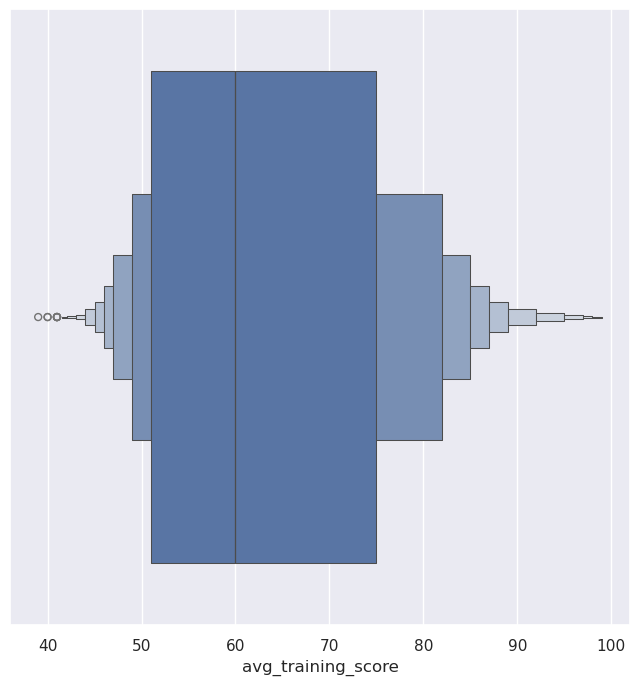

In [22]:
# Distribucion
sns.boxenplot(x=data['avg_training_score']);

> El puntaje promedio de capacitación se concentra entre 50 y 75 puntos, con una media de 63.4 y una leve asimetría positiva, lo que indica un grupo reducido de empleados con puntajes muy altos.

## Empleados por regiones

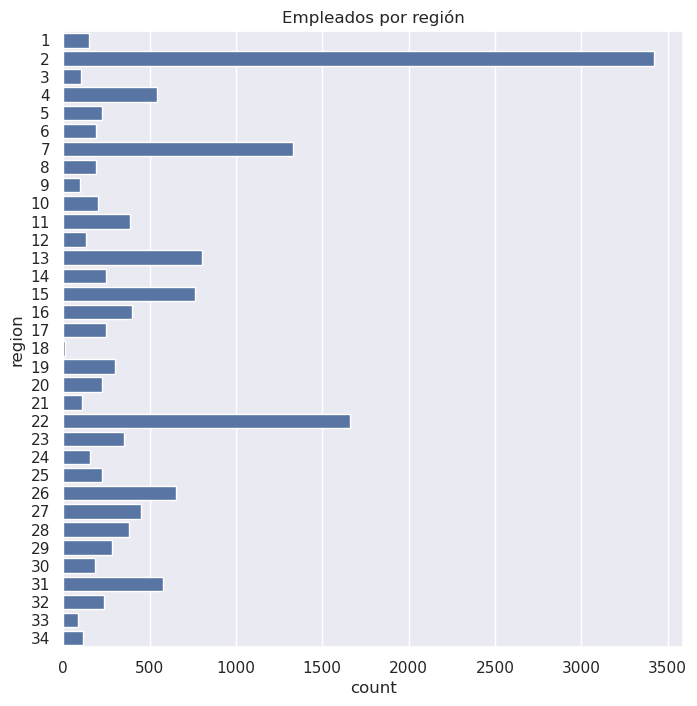

In [51]:
# Visualizacion
sns.countplot(data=data, y='region')
plt.title('Empleados por región');

> La región 2 concentra cerca del 22% del total de empleados, muy por encima del resto de regiones; la distribución geográfica de los empleados es altamente desigual.

## Empleados por departamento

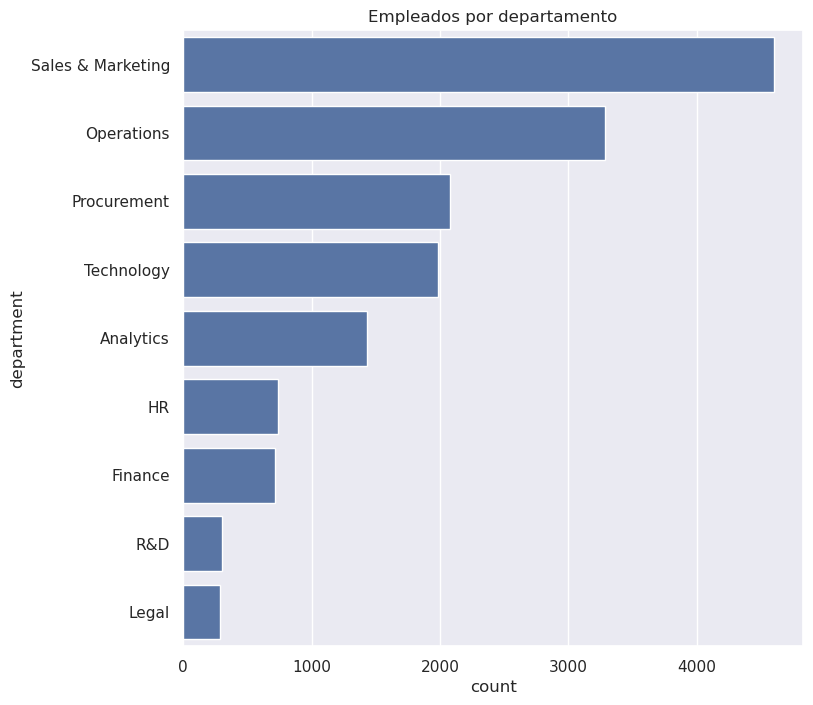

In [24]:
# obtener solo los nombres de los departamentos
order = data['department'].value_counts().index

# visualizacion
sns.countplot(data=data, y='department', order=order)
plt.title('Empleados por departamento');

> Sales & Marketing (4599) y Operations (3282) son los departamentos con más empleados, mientras que Legal (287) y R&D (299) son los más pequeños.

## Puntaje promedio de capacitación por departamento

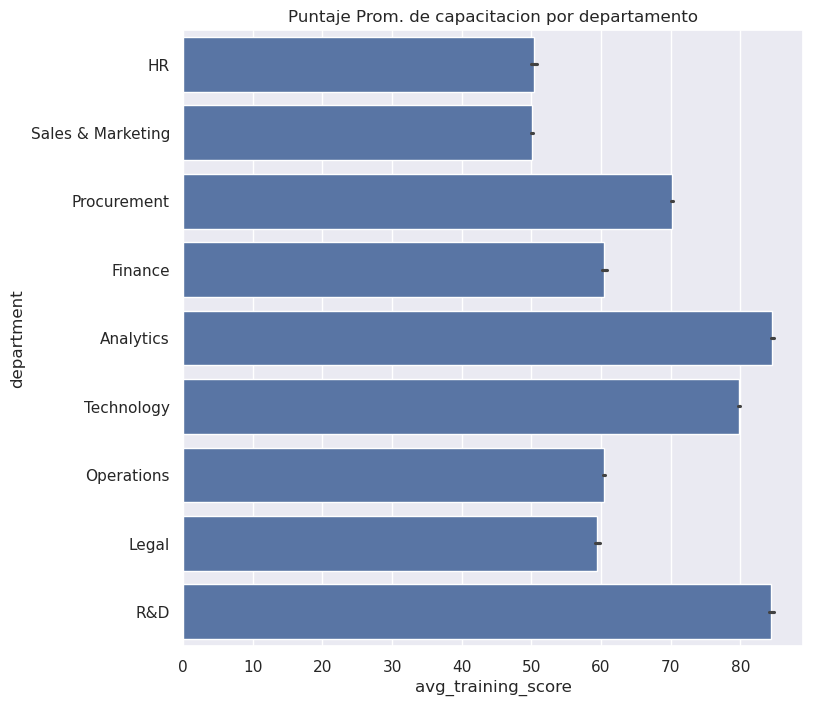

In [25]:
sns.barplot(data=data, x='avg_training_score', y='department')
plt.title('Puntaje Prom. de capacitacion por departamento');

> Analytics y R&D tienen los puntajes promedios de capacitación más altos (entre 84 y 85), mientras que Sales & Marketing y HR presentan los más bajos (cerca de 50).

> Se evidencia diferencias importantes en el desarrollo de habilidades según el área.

## Tasa de KPIs por departamento

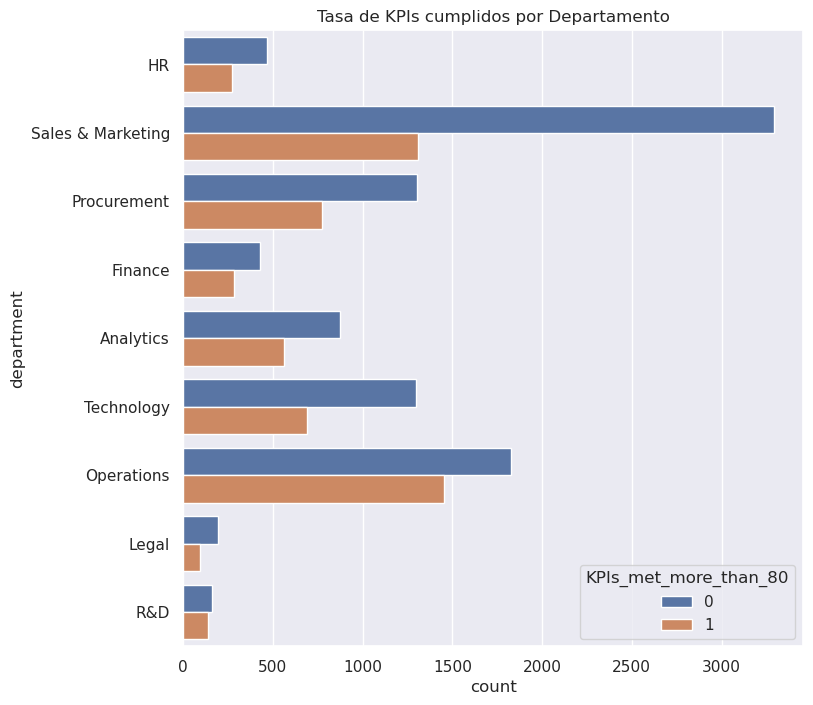

In [26]:
sns.countplot(data=data, y="department", hue="KPIs_met_more_than_80")
plt.title('Tasa de KPIs cumplidos por Departamento');

> Sales & Marketing es el departamento con la menor tasa de cumplimiento de KPIs. Se refleja en la diferencia entre la barra de empleados que no cumplió más del 80% de sus KPIs (barra 0) y la barra de empleados que sí cumplió más del 80% de sus KPIs (barra 1).

> El departamento R&D presenta la tasa más alta de cumplimiento de KPIs.

## Análisis del departamento de marketing y ventas

In [27]:
# Agrupamos los datos por departamento
grouped = data.groupby('department')

# obtener las filas de solamente el departamento de Marketing y ventas
sales_marketing_data = grouped.get_group('Sales & Marketing')
sales_marketing_data

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
1,Sales & Marketing,13,Bachelors,m,other,1,31,1.0,4,0,0,47
9,Sales & Marketing,16,Bachelors,m,sourcing,2,40,5.0,12,1,0,50
10,Sales & Marketing,17,Masters & above,m,sourcing,1,40,3.0,10,0,0,46
11,Sales & Marketing,4,Masters & above,f,other,1,34,3.0,4,0,0,52
14,Sales & Marketing,7,Bachelors,m,sourcing,1,31,4.0,4,1,0,47
...,...,...,...,...,...,...,...,...,...,...,...,...
15405,Sales & Marketing,1,Bachelors,f,sourcing,1,28,3.0,2,1,0,46
15407,Sales & Marketing,25,Masters & above,m,sourcing,1,39,5.0,9,1,0,51
15409,Sales & Marketing,24,Bachelors,m,sourcing,1,26,2.0,2,0,0,44
15411,Sales & Marketing,31,Bachelors,m,other,1,42,3.0,10,0,0,53


### Cantidad empleados por género

In [28]:
smale_count = (sales_marketing_data['gender'] == 'm').sum()
sfemale_count = (sales_marketing_data['gender'] == 'f').sum()

print('el total de empleado hombres en Sales/Marketing es de: ',smale_count)
print('el total de empleado mujeres en Sales/Marketing es de: ',sfemale_count)

el total de empleado hombres en Sales/Marketing es de:  3711
el total de empleado mujeres en Sales/Marketing es de:  888


### Gráfica de empleados por género

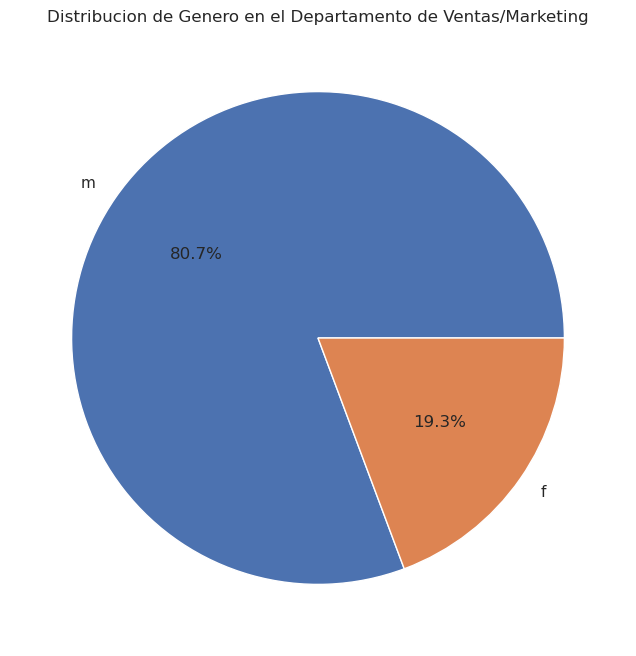

In [29]:
# conteo de generos del departamento de ventas y marketing
sgender_count = sales_marketing_data['gender'].value_counts()

# Grafico
plt.pie(sgender_count, labels=sgender_count.index, autopct='%1.1f%%')
plt.title('Distribucion de Genero en el Departamento de Ventas/Marketing');

> En el departamento de Ventas/Marketing la proporción de hombres (80.7%) es aún mayor que en el total de la empresa, lo que indica una concentración de género masculino más marcada en esta área.

### Distribución de la duración del trabajo

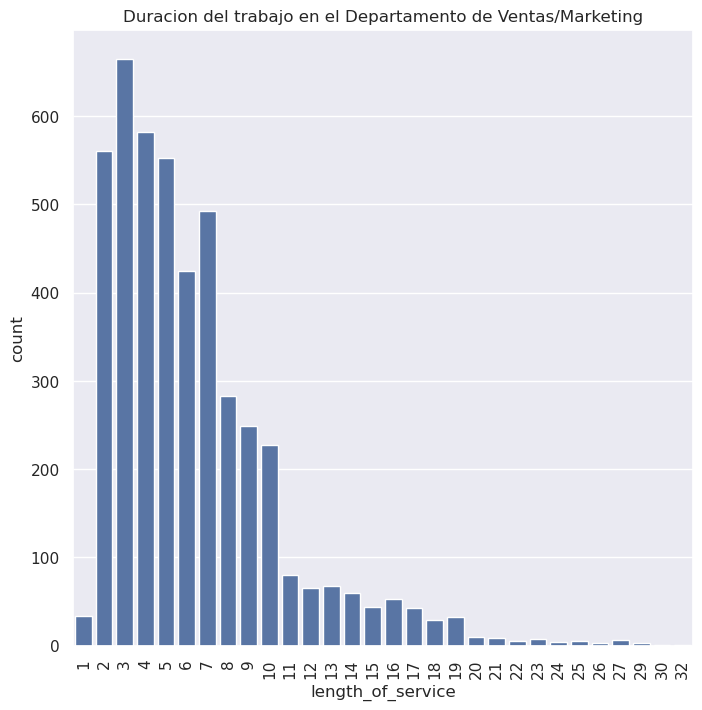

In [30]:
sns.countplot(data=sales_marketing_data, x='length_of_service')
plt.xticks(rotation=90)
plt.title('Duracion del trabajo en el Departamento de Ventas/Marketing');

> La mayoría de los empleados de este departamento tienen entre 2 y 7 años de antigüedad.

### Calificación del año en Ventas y Marketing

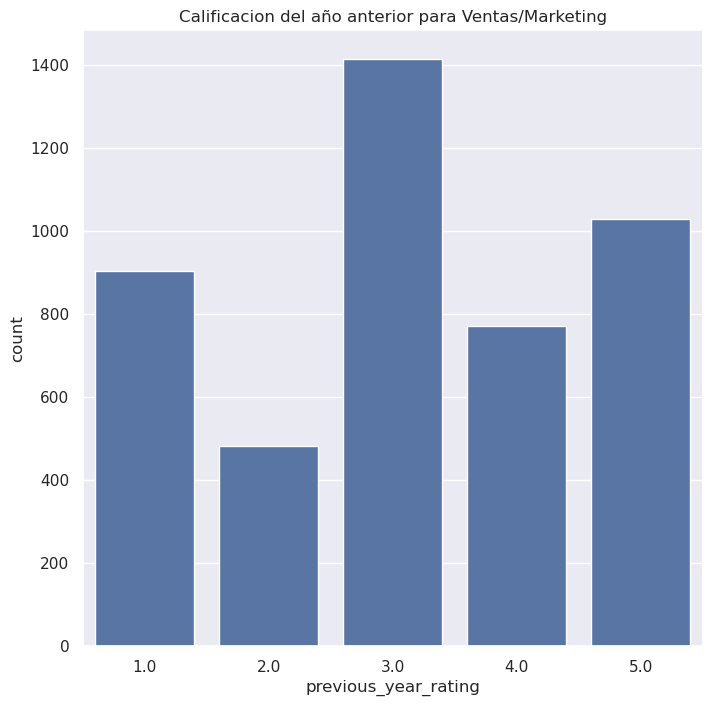

In [31]:
sns.countplot(data=sales_marketing_data, x='previous_year_rating')
plt.title('Calificacion del año anterior para Ventas/Marketing');

> La calificación 3 es la más frecuente entre los empleados de Ventas/Marketing.

> La calificación 2 es la menos común.

## Análisis empleados por premios ganados

In [32]:
# agrupamos la data por premios ganados
grouped = data.groupby('awards_won')

# obtenemos los empleados que hayan ganado premios
award_won_data = grouped.get_group(1)

# mostramos registros
award_won_data.head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
23,Operations,20,Bachelors,m,other,1,33,3.0,7,1,1,62
111,Technology,31,Masters & above,m,other,1,39,5.0,4,0,1,81
228,Procurement,15,Bachelors,m,other,1,38,4.0,2,1,1,97
257,Procurement,31,Masters & above,f,other,1,37,3.0,2,1,1,97
261,Operations,4,Masters & above,f,sourcing,2,36,1.0,6,1,1,65


### Premios ganados por género

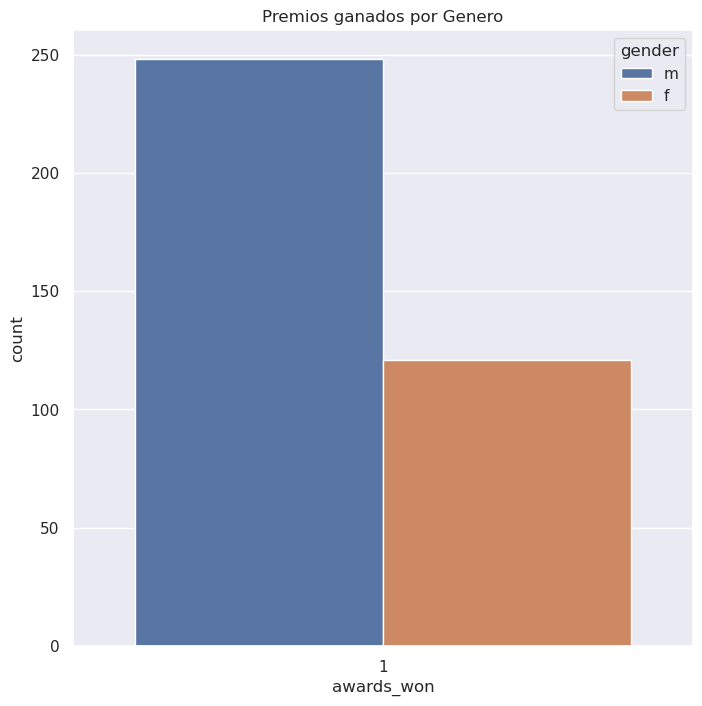

In [33]:
# Plot
sns.countplot(data=award_won_data, x='awards_won', hue='gender')
plt.title('Premios ganados por Genero');

> Los hombres ganan hasta el doble de premios que las mujeres.

### Premios ganados por edad

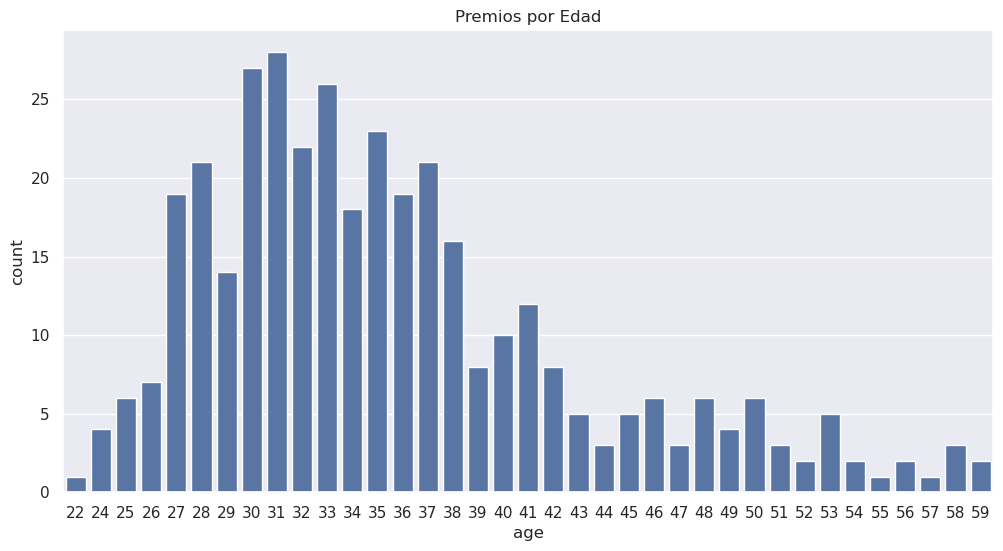

In [34]:
# Plot
plt.figure(figsize=(12,6))
sns.countplot(data=award_won_data, x='age')
plt.title('Premios por Edad');

> Empleados con edad entre 27 y 37 años reciben mayor cantidad de premios.

## Análisis de empleados que lograron más del 80% de los KPIs

In [35]:
# agrupar datos
grouped = data.groupby('KPIs_met_more_than_80')

# Obtener empleados que hayan cumplido con la meta
kpi_data = grouped.get_group(1)

# mostrar registros
kpi_data.head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
5,Finance,2,Bachelors,m,other,1,33,5.0,3,1,0,57
8,Technology,22,Bachelors,m,sourcing,1,29,5.0,2,1,0,76
9,Sales & Marketing,16,Bachelors,m,sourcing,2,40,5.0,12,1,0,50
13,Operations,11,Bachelors,m,sourcing,1,30,5.0,6,1,0,58
14,Sales & Marketing,7,Bachelors,m,sourcing,1,31,4.0,4,1,0,47


### KPIs logrados por género

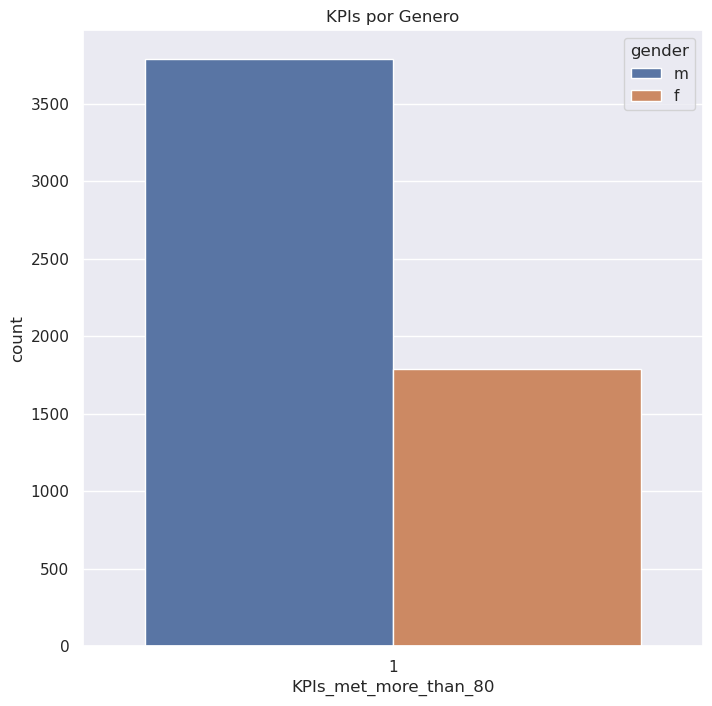

In [52]:
# Plot
sns.countplot(data=kpi_data, x='KPIs_met_more_than_80', hue='gender')
plt.title('KPIs por Genero');

> Entre los que cumplieron, hay más hombres que mujeres.

### KPIs logrados por edad

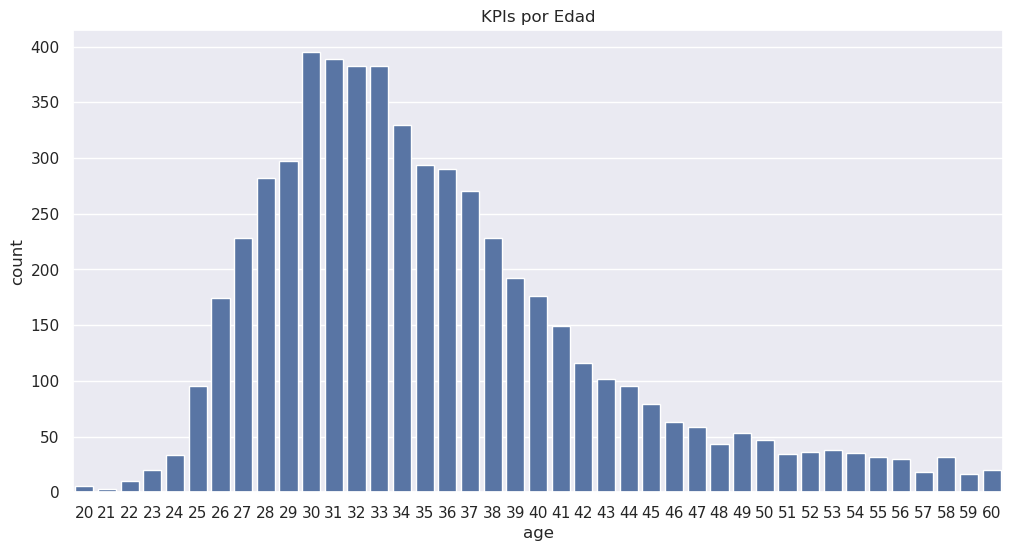

In [37]:
plt.figure(figsize=(12,6))
sns.countplot(data=kpi_data, x='age')
plt.title('KPIs por Edad');

> La mayoría de los empleados que cumplen con sus KPIs están en un rango de edad entre 26 y 40 años.

## Análisis de la frecuencia de distribución de las variables numéricas

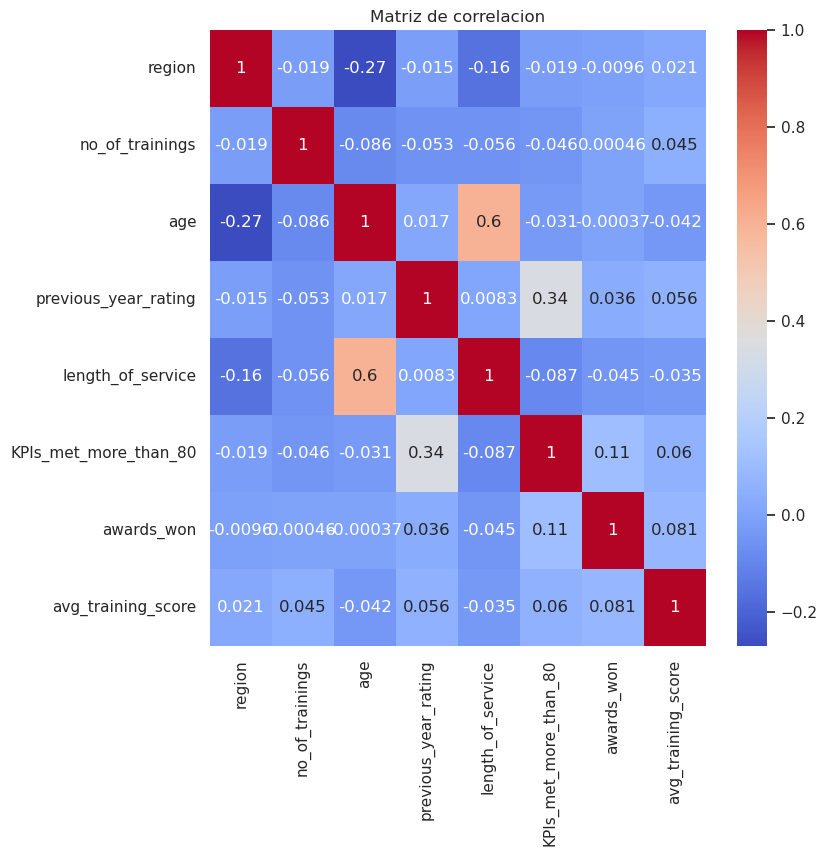

In [38]:
correlation_matrix = data.select_dtypes(include='number').corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de correlacion');

> Edad y duración del trabajo (0.60), y calificación del año anterior con cumplimiento de KPIs (0.34) son las correlaciones más fuertes.

### Distribución de edad de los empleados

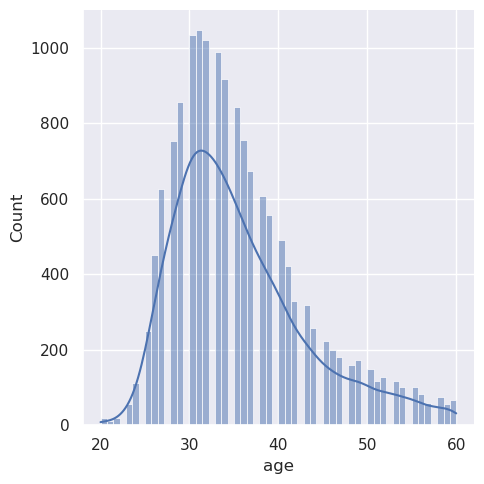

In [39]:
sns.displot(data=data, x='age', kde=True);

> La distribución de edad confirma la concentración de empleados entre los 28 y 40 años, con una cola hacia edades mayores, es decir, la mayoría de los empleados son relativamente jóvenes.

### Distribución de duración en el trabajo

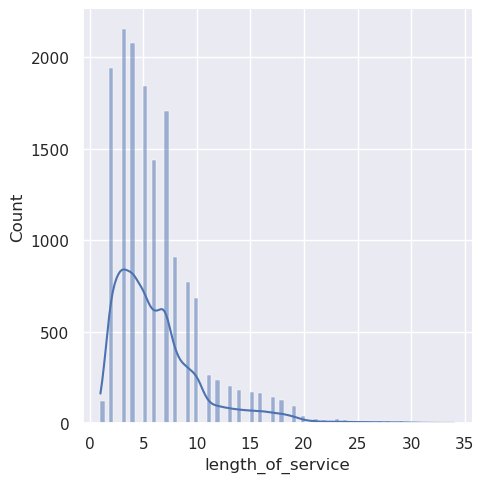

In [40]:
sns.displot(data=data, x='length_of_service', kde=True);

> La mayoría de los empleados se concentra entre 1 y 8 años de antigüedad, con pocos casos superando los 15 años. La mayoría de empleados son, en general, jóvenes en términos de permanencia, con alta rotación o incorporación reciente de personal.

### Distribución del puntaje de capacitación

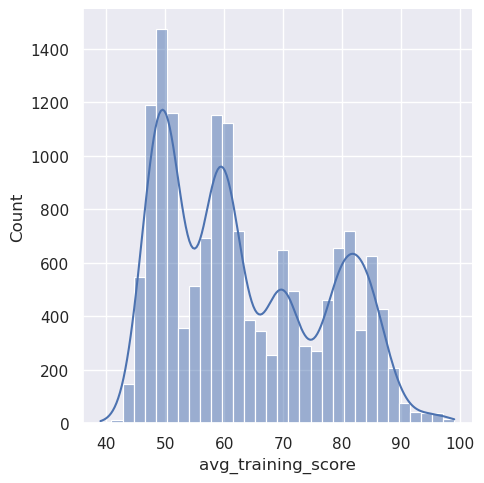

In [41]:
sns.displot(data=data, x='avg_training_score', kde=True);

> Muestra una distribución con dos concentraciones: un grupo mayoritario alrededor de 50-60 puntos y otro secundario cerca de 80-85.

> Esto coincide con las diferencias observadas entre departamentos técnicos (Analytics, R&D, Technology) y no técnicos (Sales & Marketing, HR), que tienden a formar esos dos grupos separados.

### Distribución de la región según KPIs logrados

<Figure size 1200x600 with 0 Axes>

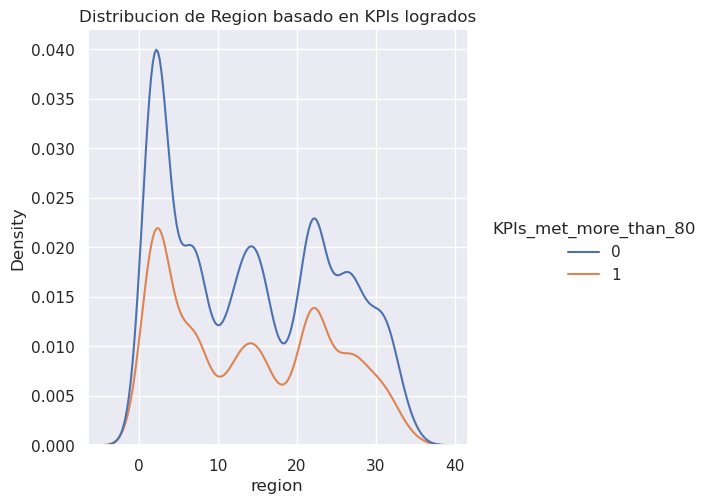

In [42]:
plt.figure(figsize=(12,6))
sns.displot(data=data, x='region', kind='kde', hue='KPIs_met_more_than_80')
plt.title('Distribucion de Region basado en KPIs logrados');

> Las curvas de densidad de la región son muy similares entre quienes cumplen y no cumplen KPIs.

> El cumplimiento de KPIs no está concentrado en regiones específicas.

### Distribución de región según la educación

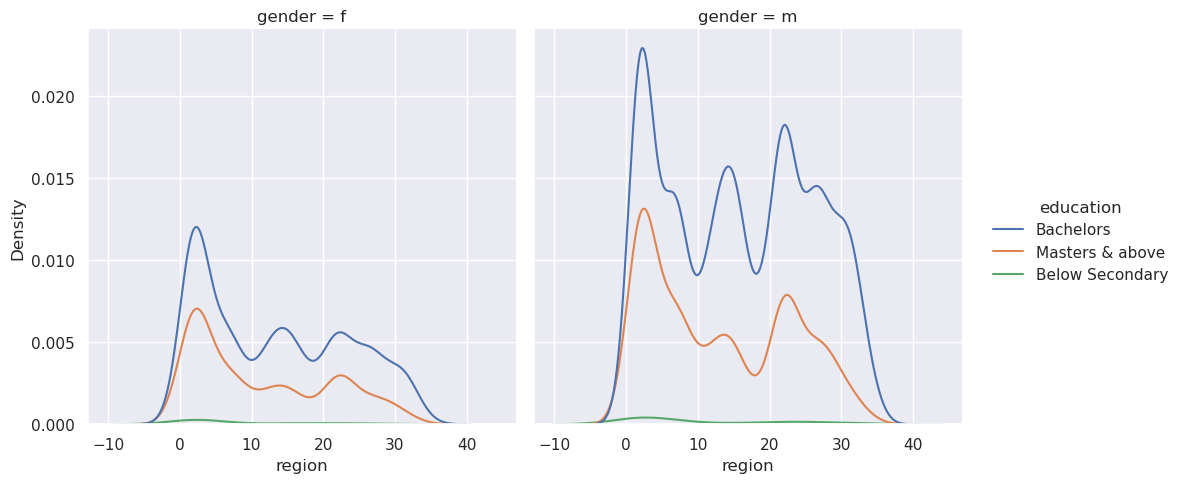

In [43]:
sns.displot(data=data, x='region', hue='education', col='gender', kind='kde');

> Las curvas de densidad de la región por nivel educativo es muy similar entre hombres y mujeres.

> El nivel educativo no varía según el género dentro de cada región. Las diferencias que se muestran se deben más a la región en sí que al género.

### Distribución de edad según el departamento y el género

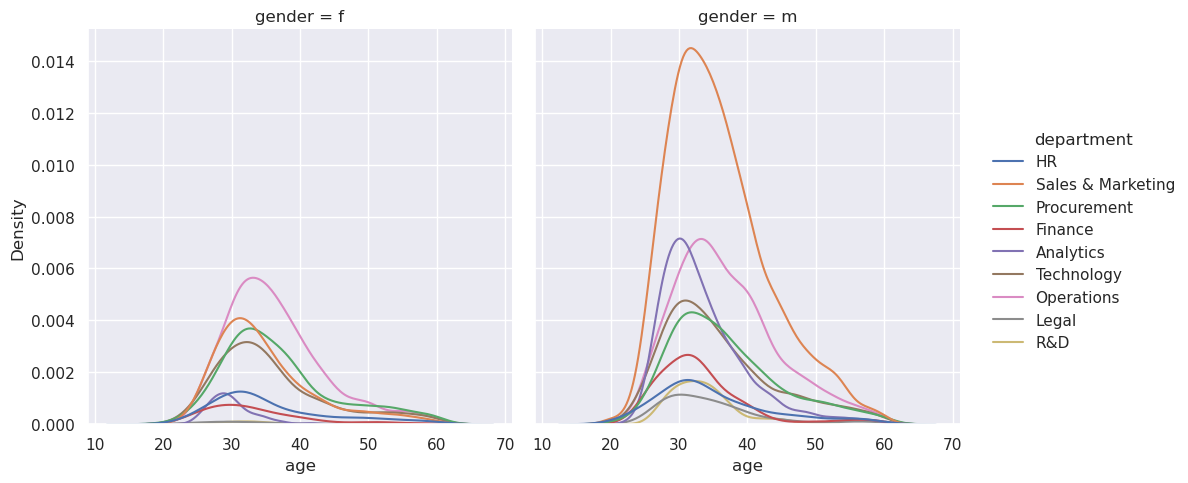

In [44]:
sns.displot(data=data, x='age', hue='department', col='gender', kind='kde');

> La distribución de edad por departamento es muy similar entre hombres y mujeres, con edades que oscilan entre 33 y 37 años.

### Distribución de puntaje de capacitación por departamento

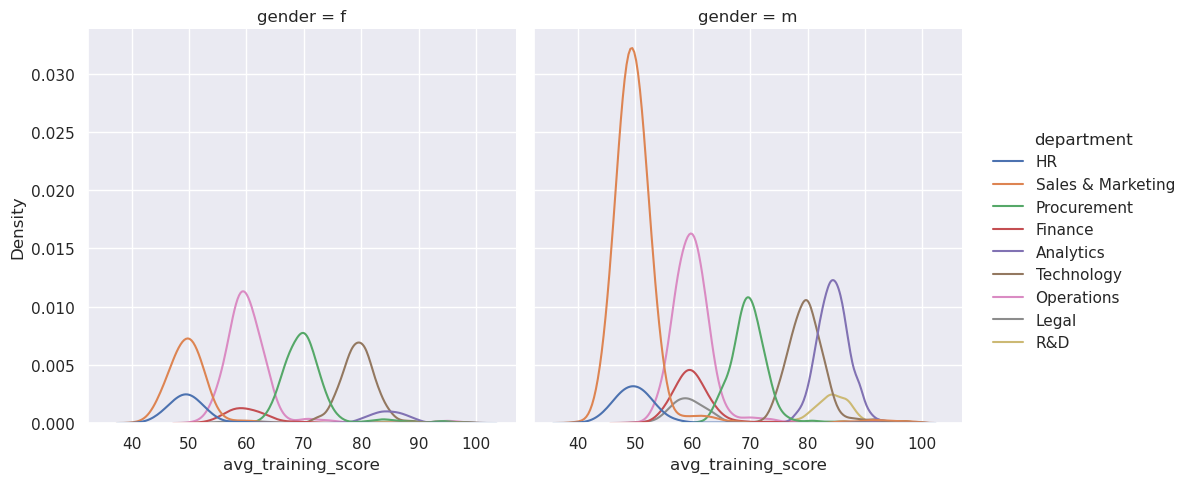

In [45]:
sns.displot(data=data, x='avg_training_score', hue='department', col='gender', kind='kde');

> Las diferencias de puntaje de capacitación entre departamentos se mantienen consistentes tanto para hombres como para mujeres.

> El puntaje depende del departamento, no del género.

## Análisis de correlación

### Duración del trabajo vs edad basado en el cumplimiento de KPIs

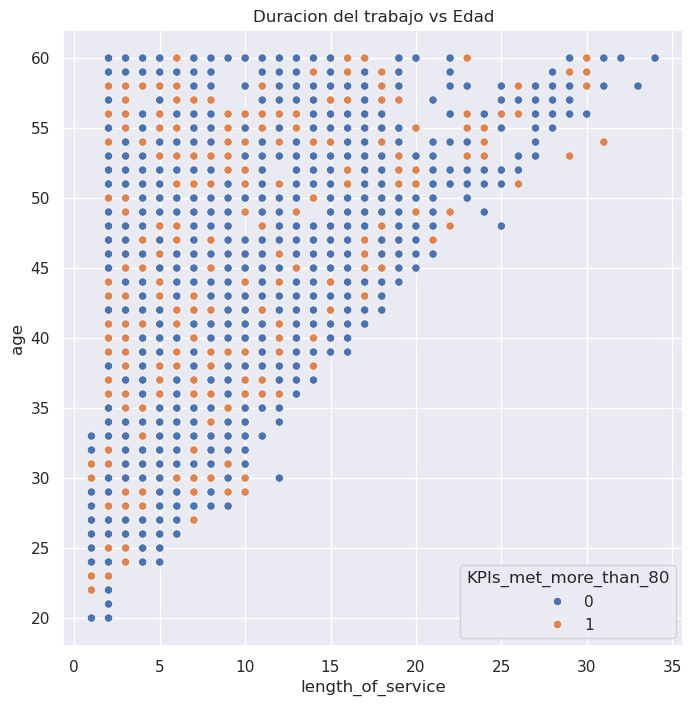

In [46]:
# Plot
sns.scatterplot(data=data, x='length_of_service', y='age', hue='KPIs_met_more_than_80')
plt.title('Duracion del trabajo vs Edad');

> A mayor edad, mayor antigüedad.

> No muestra una clara separación entre quienes cumplen y no cumplen KPIs, lo que indica que el desempeño en KPIs no depende de la combinación edad/antigüedad.

### Edad vs duración del trabajo basado en el género

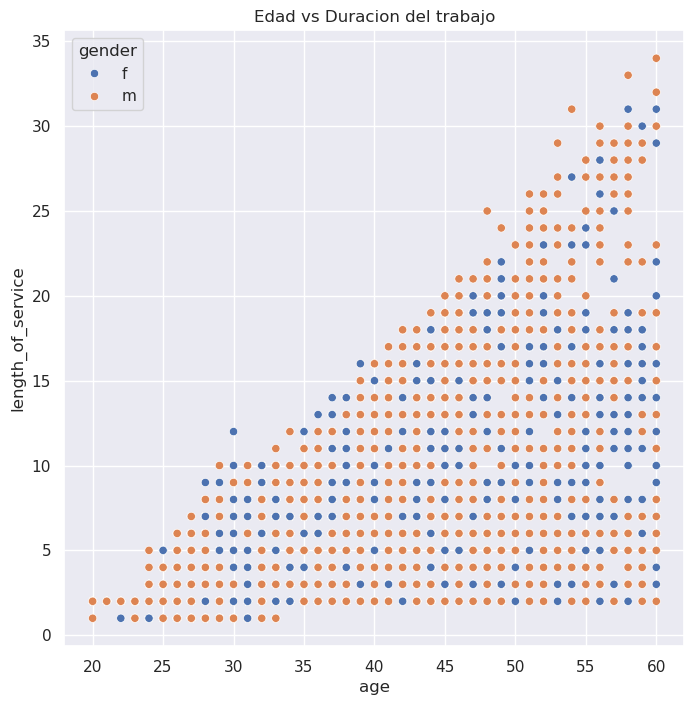

In [47]:
sns.scatterplot(data=data, x='age', y='length_of_service', hue='gender')
plt.title('Edad vs Duracion del trabajo');

> Ambos géneros siguen una relación entre edad y antigüedad similar. A mayor edad, mayor duración en el trabajo.

### Puntaje de capacitación vs duración del trabajo basado en el género

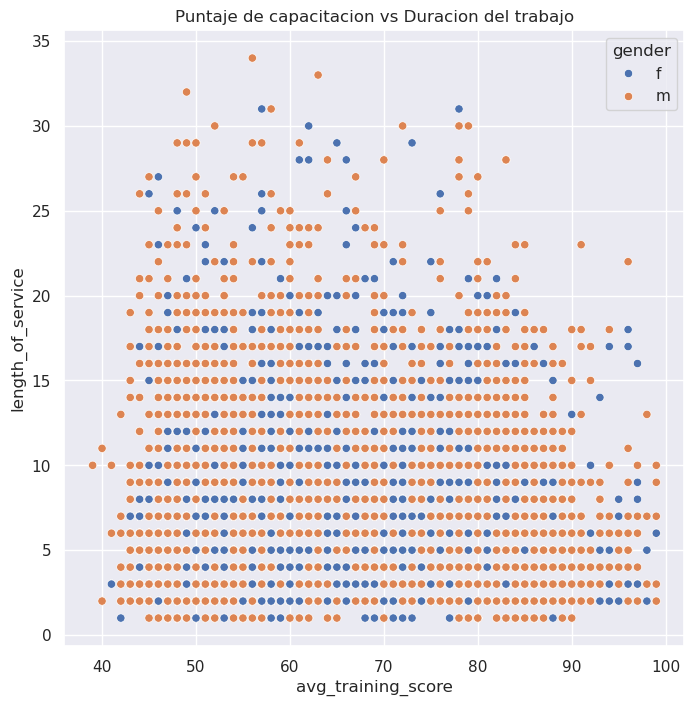

In [48]:
sns.scatterplot(data=data, x='avg_training_score', y='length_of_service', hue='gender')
plt.title('Puntaje de capacitacion vs Duracion del trabajo');

> No se evidencia una relación clara entre puntaje de capacitación y duración del trabajo.

### Correlación entre dos variables numéricas y 3 categóricas

In [53]:
data.head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,HR,4,Bachelors,f,other,1,31,3.0,5,0,0,51
1,Sales & Marketing,13,Bachelors,m,other,1,31,1.0,4,0,0,47
2,Procurement,2,Bachelors,f,other,3,31,2.0,9,0,0,65
3,Finance,29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61
4,Procurement,7,Bachelors,m,sourcing,1,36,3.0,2,0,0,68


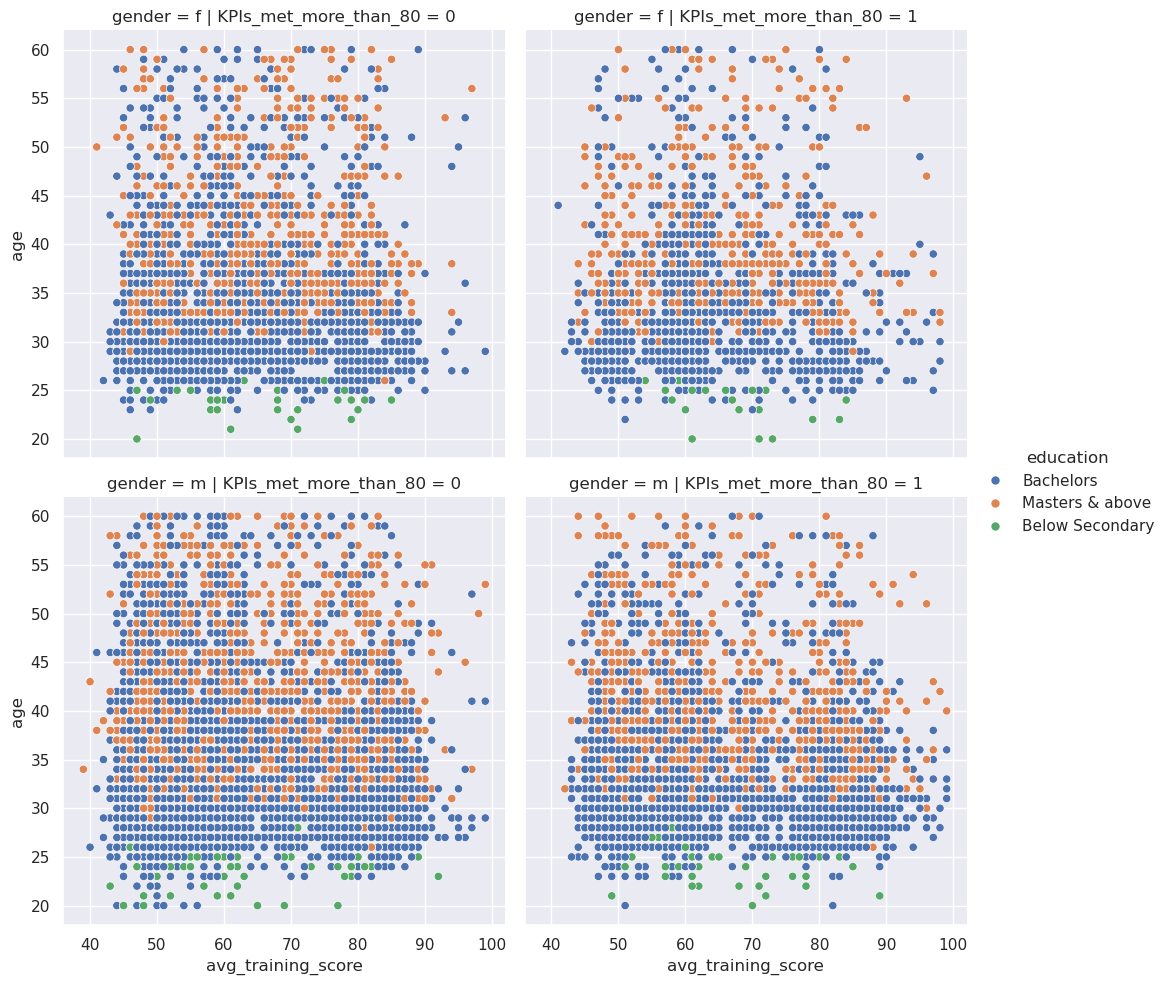

In [49]:
# variables numericas: avg_training_score, age
# variables categoricas: education, KPIs_met_more_than_80, gender

sns.relplot(data=data, x='avg_training_score', y='age', hue='education', col='KPIs_met_more_than_80', row='gender');

## Conclusiones generales

1. Hay un desbalance entre hombres y mujeres que trabajan en la empresa: 70% hombres y 30% mujeres. Esta diferencia es muy marcada en el departamento Sales & Marketing (80.7%). Sin embargo, las mujeres tienen una tasa de cumplimiento de KPIs ligeramente superior (38.8%), lo que sugiere que el género no es un factor limitante de desempeño, a pesar de la disparidad numérica.

2. los KPIs cumplidos, el puntaje de capacitación y los premios varían fuertemente por área, pero apenas cambian según género o edad. El departamento es el factor explicativo dominante.

3. Sales & Marketing es el área con más empleados (4599) pero también la de menor cumplimiento de KPIs (28%) y menor puntaje de capacitación (cerca de 50), lo que la convierte en el área con mayor impacto potencial si se interviniera, dado su tamaño.

4. El puntaje de capacitación presenta un comportamiento bimodal (cerca de 50 en Sales/HR y entre 84 y 85 en Analytics/R&D), reflejando una división estructural en el desarrollo de competencias según el tipo de rol.

5. La mayoría de los empleados tiene entre 28 y 40 años y entre 1 y 8 años de antigüedad, con baja participación en capacitación (la mayoría solo ha tomado 1). Esto sugiere una fuerza laboral en crecimiento y renovación.

6. El canal de ingreso y el nivel educativo están distribuidos de forma similar entre géneros y regiones.

7. Solo edad vs antigüedad (0.60, esperable) y calificación previa vs KPIs (0.34, moderada) muestran una relación lineal relevante. Esto indica que el cumplimiento de KPIs no se explica bien por variables individuales simples, por lo que se necesitarían modelos que consideren el departamento como variable central, o técnicas no lineales, para predecir el desempeño con mayor precisión.

> En síntesis, la variable que más explica las diferencias de desempeño, capacitación y premios es el departamento, no el género ni la edad. El mayor punto de mejora identificable es Sales & Marketing, tanto por su tamaño como por sus resultados más bajos.